# CRVSE Phase B - Ensemble rPPG - CRVSETransformer family (Round 4) part 1 - ensemble only (1ch)

### What this notebook does

Trains the attention-based model family (`CRVSETransformer` global self-attention, `CRVSEPhysFormer` CNN+FFT+Transformer, `CRVSELocalAttention` sliding-window attention) on ensemble rPPG signals (POS + CHROM + GREEN).

**Input mode `ensemble_only`** - the pre-fused, quality-weighted ensemble signal as a single input channel `(1, 240)`. Establishes whether the ensemble fusion itself carries enough information for the attention models.

Runs **three Optuna studies** (Transformer + PhysFormer + LocalAttention, all on the single ensemble channel), retrains the best configuration of each on train+val, evaluates on the held-out test set, and compares the three variants.


> **PhysFormer note:** the FFT path uses a channel-averaged magnitude spectrum, so the same class is valid for both 1-channel and 3-channel input (identical to the original for 1ch).

## 1. Imports and Config

In [1]:
import h5py, torch, os, optuna, json, math
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy import stats
from scipy.signal import resample
from collections import defaultdict, Counter
from tqdm import tqdm
from typing import Callable

#  Paths  (ensemble HDF5 files: POS + CHROM + GREEN + pre-fused ensemble)
H5_PATHS = {
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/mcd_rppg_ensemble.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_rppg_ensemble.h5",
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_phys_ensemble.h5",
    "ecg_fitness" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ecg_fitness_ensemble.h5",
}

# SQI gates per dataset
# Thresholds calibrated during preprocessing (see NB06/NB07/NB08).
# MCD-rPPG 0.10 : recalibrated (ensemble scale differs from POS-only)
# UBFC-rPPG 0.07: original threshold, clean lab conditions
# UBFC-Phys 0.05: lowered - 35fps + 1024x1024 + stress tasks lower spectral SQI
DATASET_SQI_THRESHOLDS = {
    "mcd_rppg" : 0.10,
    "ubfc_rppg" : 0.07,
    "ubfc_phys" : 0.05,
    "ecg_fitness" : 0.07,
}

# Fixed config
MODEL_NAME = "CRVSETransformer_Ensemble"
INPUT_MODE = "ensemble_only"
IN_CHANNELS = 1 # pre-fused quality-weighted ensemble
STUDY_TAG = "ens_single" # suffix appended to each architecture's study name

HR_MIN = 40.0
HR_MAX = 180.0
MAX_NAN_FRAC = 0.10
TARGET_FRAMES = 240
WINDOW_SEC = 8
STRIDE_SEC = 4
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config
N_TRIALS = 50
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5

print(f"Device : {DEVICE}")
print(f"Model family : {MODEL_NAME}")
print(f"Input mode : {INPUT_MODE} ({IN_CHANNELS} channel)")
print(f"Trials/study : {N_TRIALS} | Max epochs/trial : {N_EPOCHS} | 3 studies (Transformer + PhysFormer + LocalAttention)")
print(f"Datasets : {list(H5_PATHS.keys())}")
print(f"SQI thresholds : {DATASET_SQI_THRESHOLDS}")

Device : cuda
Model family : CRVSETransformer_Ensemble
Input mode : ensemble_only (1 channel)
Trials/study : 50 | Max epochs/trial : 50 | 3 studies (Transformer + PhysFormer + LocalAttention)
Datasets : ['mcd_rppg', 'ubfc_rppg', 'ubfc_phys', 'ecg_fitness']
SQI thresholds : {'mcd_rppg': 0.1, 'ubfc_rppg': 0.07, 'ubfc_phys': 0.05, 'ecg_fitness': 0.07}


## 2. Window Extractor

In [2]:
def extract_windows(signals: dict, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec: int,
                    target_frames: int, max_nan_frac: float, hr_min: float, hr_max: float) -> list:
    """
    Extract sliding windows from one recording.

    Returns:
        list of dicts, each containing:
            pos_win, chrom_win, green_win, ensemble_win : (target_frames,) float32
            hr_label : scalar float, nanmean of hr_cont over the window.
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(hr_cont)
    results = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames
        hr_win = hr_cont[start:end]

        # Gate 1: NaN fraction on HR label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue

        # Gate 2: scalar HR label inside physiological range
        hr_label = float(np.nanmean(hr_win))
        if not (hr_min <= hr_label <= hr_max):
            continue

        # Process each signal channel
        win_dict = {}
        skip = False

        for key in ("pos", "chrom", "green", "ensemble"):
            sig_win = signals[key][start:end]

            # Gate 3: NaN on signal
            if np.any(np.isnan(sig_win)):
                skip = True
                break

            # Resample to fixed length
            if len(sig_win) != target_frames:
                sig_win = resample(sig_win, target_frames).astype(np.float32)

            # Gate 4: flat signal (std < 1e-6 means no pulse information)
            std = sig_win.std()
            if std < 1e-6:
                skip = True
                break

            # Z-score per window per channel
            sig_win = ((sig_win - sig_win.mean()) / std).astype(np.float32)
            win_dict[f"{key}_win"] = sig_win

        if skip:
            continue

        win_dict["hr_label"] = hr_label
        results.append(win_dict)

    return results

## 3. Index Builder

Reads all HDF5 files once and builds a flat list of window dicts. All four signal channels (POS, CHROM, GREEN, ensemble) are stored per window. SQI gating is applied per dataset before windowing.

In [3]:
def build_index(h5_paths: dict, sqi_thresholds: dict, window_sec: int, stride_sec: int, target_frames: int,
                max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Builds flat window index from all ensemble HDF5 files.

    SQI gate: recordings with sqi_ensemble < sqi_thresholds[dataset] are skipped.
    Threshold is dataset-specific - calibrated in preprocessing NBs.

    Returns:
        samples : list of window dicts (all channels pre-computed)
        subject_keys : sorted list of unique subject keys for split.
    """
    samples = []
    subject_keys = set()
    skipped_sqi = 0

    for dataset_name, path in h5_paths.items():
        if not os.path.exists(path):
            print(f"[WARN] Not found, skipping: {path}")
            continue

        sqi_gate = sqi_thresholds.get(dataset_name, 0.07)

        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]

                    # SQI gate - skip recording before any signal read
                    sqi_ens = float(rec.attrs.get("sqi_ensemble", 1.0))
                    if sqi_ens < sqi_gate:
                        skipped_sqi += 1
                        continue

                    fps = float(rec.attrs["fps"])
                    hr_cont = rec["hr_continuous"][:]

                    # Read all four signals - stored for both study modes
                    signals = {
                        "pos" : rec["rppg_pos"][:],
                        "chrom" : rec["rppg_chrom"][:],
                        "green" : rec["rppg_green"][:],
                        "ensemble" : rec["rppg_ensemble"][:],
                    }

                    wins = extract_windows(signals, hr_cont, fps, window_sec, stride_sec,
                                           target_frames, max_nan_frac, hr_min, hr_max)
                    for w in wins:
                        w["subject_key"] = subj_key
                        w["dataset"] = dataset_name
                        samples.append(w)

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    print(f"Recordings skipped (SQI) : {skipped_sqi}")

    # Per-dataset breakdown
    ds_counts = Counter(s["dataset"] for s in samples)
    print("\nPer-dataset window counts:")
    for ds, n in sorted(ds_counts.items()):
        print(f"{ds:<15} : {n:>6} windows")

    return samples, sorted(subject_keys)

## 4. Subject-Level Train/Val/Test Split

In [4]:
def subject_split(subject_keys: list, train_frac: float = 0.7, val_frac: float = 0.15, seed: int = 42) -> tuple:
    """
    Subject-level split. No subject appears in more than one split.
    test_frac = 1 - train_frac - val_frac
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys = set(keys[:n_train])
    val_keys = set(keys[n_train : n_train + n_val])
    test_keys = set(keys[n_train + n_val:])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset Class

Assemble the input tensor from pre-built window dicts based on `input_mode`:

* `ensemble_only` -> `(1, 240)` single pre-fused quality-weighted channel
* `multichannel`  -> `(3, 240)` stacked [POS, CHROM, GREEN]

In [5]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase B ensemble rPPG -> HR estimation.

    Args:
        samples : list of window dicts from build_index()
        subject_set : set of subject_key strings to include (train/val/test)
        input_mode : `ensemble_only` | `multichannel` - controls which signals
                     are assembled into the input tensor.
    """
    def __init__(self, samples: list, subject_set: set, input_mode: str = "multichannel") -> None:
        self.input_mode = input_mode
        self.items = [s for s in samples if s["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows (mode={input_mode})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple:
        item = self.items[idx]

        if self.input_mode == "ensemble_only":
            # Shape: (1, 240) - single pre-fused channel
            signal = torch.tensor(item["ensemble_win"], dtype=torch.float32).unsqueeze(0)
        else:
            # Shape: (3, 240) - 3 independent algorithm outputs
            signal = torch.stack([
                torch.tensor(item["pos_win"], dtype=torch.float32),
                torch.tensor(item["chrom_win"], dtype=torch.float32),
                torch.tensor(item["green_win"], dtype=torch.float32),
            ])

        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label

## 6. Model Architecture



### Shared building blocks - PositionalEncoding + custom encoder layer

In [6]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding. Transformers have no inherent sense of temporal
    order without this.
    """
    def __init__(self, d_model: int, max_len: int = 300, dropout: float = 0.1) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerEncoderLayerCustom(nn.Module):
    """
    Replacement for nn.TransformerEncoderLayer. Avoids the PyTorch 2.x dtype check bug
    on src_mask. Pre-norm architecture: more stable on small datasets.
    """
    def __init__(self, d_model: int, n_heads: int, dim_feedforward: int = 256, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % n_heads == 0, f"d_model ({d_model}) must be divisible by n_heads ({n_heads})"

        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def _attention(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape

        Q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, T, T)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V) # (B, H, T, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, T, -1) # (B, T, d_model)
        return self.out_proj(out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-norm residual
        x = x + self.dropout(self._attention(self.norm1(x)))
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x

### Model A - CRVSETransformer (global self-attention)

In [7]:
class CRVSETransformer(nn.Module):
    """
    CNN encoder + standard global self-attention Transformer.

    The CNN extracts local pulse morphology features; the Transformer models global
    temporal dependencies (every timestep attends to every other timestep).

    Args:
        in_channels : input channels (1 for ensemble_only, 3 for multichannel)
        cnn_channels : CNN output channels = Transformer d_model
        n_heads : attention heads (must divide cnn_channels)
        n_layers : Transformer encoder depth
        dim_feedforward : FFN hidden size (typically 4 x d_model)
        dropout : dropout throughout
    """
    def __init__(self, in_channels: int = 1, cnn_channels: int = 64, n_heads: int = 4, n_layers: int = 2,
                 dim_feedforward: int = 256, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        assert cnn_channels % n_heads == 0, f"cnn_channels ({cnn_channels}) must be divisible by n_heads ({n_heads})"

        self.hr_min = hr_min
        self.hr_max = hr_max

        # CNN Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, cnn_channels // 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels // 2, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Positional Encoding
        self.pos_enc = PositionalEncoding(cnn_channels, max_len=300, dropout=dropout)

        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderLayerCustom(
                d_model = cnn_channels,
                n_heads = n_heads,
                dim_feedforward = dim_feedforward,
                dropout = dropout,
            )
            for _ in range(n_layers)
        ])

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(cnn_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.encoder(x) # (B, C, T)
        out = out.permute(0, 2, 1) # (B, T, C)
        out = self.pos_enc(out)
        for layer in self.transformer_layers:
            out = layer(out)
        out = out.mean(dim=1) # (B, C) - GAP over time
        out = self.head(out).squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### Model B - CRVSEPhysFormer (CNN + FFT + Transformer)

In [8]:
class CRVSEPhysFormer(nn.Module):
    """
    CNN + FFT + Transformer.

    rPPG-specific inductive bias: HR information lives in a narrow frequency band
    (0.7-3.5 Hz). Concatenating an FFT-magnitude representation with the time-domain
    CNN features lets the model attend to "which frequency bin is the pulse" directly.

    Pipeline:
        Conv encoder (time domain)        -> local pulse features
        FFT magnitude (channel-averaged)  -> frequency representation
        Concat [time_features, freq_features] per position
        Transformer -> GAP -> Head

    Args:
        in_channels : input channels (1 for ensemble_only, 3 for multichannel)
        cnn_channels : CNN output = time feature dimension
        freq_channels : projection dimension for FFT features
        d_model = cnn_channels + freq_channels (transformer input)
        n_heads : attention heads (must divide d_model)
        n_layers : transformer depth
        dim_feedforward : FFN hidden size
        dropout : dropout throughout
    """
    def __init__(self, in_channels: int = 1, cnn_channels: int = 32, freq_channels: int = 32, n_heads: int = 4, n_layers: int = 2,
                 dim_feedforward: int = 256, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()

        self.hr_min = hr_min
        self.hr_max = hr_max
        self.d_model = cnn_channels + freq_channels

        assert self.d_model % n_heads == 0, f"d_model ({self.d_model}) must be divisible by n_heads ({n_heads})"

        # CNN Encoder (time domain)
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, cnn_channels // 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels // 2, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )  # Output: (B, cnn_channels, T)

        # FFT frequency projection
        # rfft of T=240 samples -> 121 frequency bins; project each to freq_channels,
        # then broadcast across T time steps for concatenation.
        n_fft_bins = TARGET_FRAMES // 2 + 1  # 121 for T=240
        self.freq_proj = nn.Sequential(
            nn.Linear(n_fft_bins, freq_channels * 4),
            nn.ReLU(),
            nn.Linear(freq_channels * 4, freq_channels),
        )

        # Positional encoding on d_model
        self.pos_enc = PositionalEncoding(self.d_model, max_len=300, dropout=dropout)

        self.transformer_layers = nn.ModuleList([
            TransformerEncoderLayerCustom(
                d_model = self.d_model,
                n_heads = n_heads,
                dim_feedforward = dim_feedforward,
                dropout = dropout,
            )
            for _ in range(n_layers)
        ])

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(self.d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, T = x.shape

        # Time-domain features
        time_feat = self.encoder(x) # (B, cnn_channels, T)
        time_feat = time_feat.permute(0, 2, 1) # (B, T, cnn_channels)

        # Frequency-domain features
        # Magnitude spectrum averaged across input channels - this makes the same
        # class valid for ensemble_only (C=1) and multichannel (C=3). For C=1 it is
        # identical to the original single-channel rfft path.
        freq = torch.fft.rfft(x, norm="ortho") # (B, C, n_fft_bins) complex
        freq_mag = freq.abs().mean(dim=1) # (B, n_fft_bins) real
        freq_feat = self.freq_proj(freq_mag) # (B, freq_channels)
        freq_feat = freq_feat.unsqueeze(1).expand(-1, T, -1)  # (B, T, freq_channels)

        # Concatenate time + frequency
        combined = torch.cat([time_feat, freq_feat], dim=-1)  # (B, T, d_model)
        combined = self.pos_enc(combined)

        for layer in self.transformer_layers:
            combined = layer(combined)

        out = combined.mean(dim=1) # (B, d_model) - GAP
        out = self.head(out).squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### Model C - CRVSELocalAttention (sliding-window attention)

In [9]:
class LocalAttentionBlock(nn.Module):
    """
    Sliding-window (local) self-attention. Each timestep attends only to its local
    neighbourhood of +/- window_size samples. Physiological justification: pulse-wave
    features (systolic peak, dicrotic notch, inter-beat interval) are local phenomena
    within an 8-second rPPG window.

    Args:
        d_model : feature dimension
        n_heads : attention heads
        window_size : each token attends to +/- window_size neighbours
        dropout : dropout on attention weights
    """
    def __init__(self, d_model: int, n_heads: int, window_size: int = 15, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % n_heads == 0, f"d_model ({d_model}) must be divisible by n_heads ({n_heads})"

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.window_size = window_size
        self.scale = self.head_dim ** -0.5
        self.dropout = nn.Dropout(dropout)

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def _build_local_mask(self, T: int, device: torch.device) -> torch.Tensor:
        idx = torch.arange(T, device=device)
        dist = (idx.unsqueeze(0) - idx.unsqueeze(1)).abs()  # (T, T)
        return dist <= self.window_size # (T, T) bool

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape

        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        def split_heads(t: torch.Tensor) -> torch.Tensor:
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        Q, K, V = split_heads(Q), split_heads(K), split_heads(V)

        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, T, T)

        # Apply local mask - block attention outside the window
        local_mask = self._build_local_mask(T, x.device) # (T, T)
        additive_mask = torch.zeros(T, T, device=x.device)
        additive_mask[~local_mask] = float("-inf")
        scores = scores + additive_mask.unsqueeze(0).unsqueeze(0)

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V)                                 # (B, H, T, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.out_proj(out)


class LocalAttentionEncoderLayer(nn.Module):
    """Full encoder layer: LocalAttention + FFN + residuals + LayerNorm (pre-norm)."""
    def __init__(self, d_model: int, n_heads: int, window_size: int = 15, dim_feedforward: int = 256, dropout: float = 0.1) -> None:
        super().__init__()
        self.attn = LocalAttentionBlock(d_model, n_heads, window_size, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.dropout(self.attn(self.norm1(x)))
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x


class CRVSELocalAttention(nn.Module):
    """
    CNN encoder + stacked local (sliding-window) attention layers.

    Args:
        in_channels : input channels (1 for ensemble_only, 3 for multichannel)
        cnn_channels : CNN output = d_model
        n_heads : attention heads
        n_layers : number of local attention layers
        window_size : local attention radius in samples
        dim_feedforward : FFN hidden size
        dropout : dropout throughout
    """
    def __init__(self, in_channels: int = 1, cnn_channels: int = 64, n_heads: int = 4, n_layers: int = 2, window_size: int = 15,
                 dim_feedforward: int = 256, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        assert cnn_channels % n_heads == 0, f"cnn_channels ({cnn_channels}) must be divisible by n_heads ({n_heads})"

        self.hr_min = hr_min
        self.hr_max = hr_max

        # CNN Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, cnn_channels // 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels // 2, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Positional Encoding
        self.pos_enc = PositionalEncoding(cnn_channels, max_len=300, dropout=dropout)

        # Local Attention Stack
        self.layers = nn.ModuleList([
            LocalAttentionEncoderLayer(
                d_model = cnn_channels,
                n_heads = n_heads,
                window_size = window_size,
                dim_feedforward = dim_feedforward,
                dropout = dropout,
            )
            for _ in range(n_layers)
        ])

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(cnn_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.encoder(x) # (B, C, T)
        out = out.permute(0, 2, 1) # (B, T, C)
        out = self.pos_enc(out)
        for layer in self.layers:
            out = layer(out) # (B, T, C)
        out = out.mean(dim=1) # (B, C) - GAP
        out = self.head(out).squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

In [10]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Sanity check - all three models at the input channel count for this notebook
dummy = torch.randn(32, IN_CHANNELS, TARGET_FRAMES)

configs = [
    ("CRVSETransformer", CRVSETransformer(in_channels=IN_CHANNELS, cnn_channels=64, n_heads=4, n_layers=2)),
    ("CRVSEPhysFormer", CRVSEPhysFormer(in_channels=IN_CHANNELS, cnn_channels=32, freq_channels=32, n_heads=4, n_layers=2)),
    ("CRVSELocalAttention", CRVSELocalAttention(in_channels=IN_CHANNELS, cnn_channels=64, n_heads=4, n_layers=2, window_size=15)),
]

print(f"Input shape : {tuple(dummy.shape)}  (mode={INPUT_MODE})")
print(f"{'Model':<25} {'Output':>14} {'Params':>12}")
print("-" * 55)
for name, model in configs:
    with torch.no_grad():
        out = model(dummy)
    print(f"{name:<25} {str(tuple(out.shape)):>14} {count_parameters(model):>12,}")

Input shape : (32, 1, 240)  (mode=ensemble_only)
Model                             Output       Params
-------------------------------------------------------
CRVSETransformer                   (32,)      125,313
CRVSEPhysFormer                    (32,)      127,809
CRVSELocalAttention                (32,)      125,313


## 7. Data Preparation


In [11]:
all_samples, all_subject_keys = build_index(
    h5_paths = H5_PATHS,
    sqi_thresholds = DATASET_SQI_THRESHOLDS,
    window_sec = WINDOW_SEC,
    stride_sec = STRIDE_SEC,
    target_frames = TARGET_FRAMES,
    max_nan_frac = MAX_NAN_FRAC,
    hr_min = HR_MIN,
    hr_max = HR_MAX,
)

train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.7, val_frac=0.15, seed=SEED)

print(f"\nTrain dataset:")
train_ds = CRVSEDataset(all_samples, train_keys, input_mode=INPUT_MODE)
print("Val dataset:")
val_ds = CRVSEDataset(all_samples, val_keys, input_mode=INPUT_MODE)
print("Test dataset:")
test_ds = CRVSEDataset(all_samples, test_keys, input_mode=INPUT_MODE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Total windows extracted : 19052
Total unique subjects : 479
Recordings skipped (SQI) : 246

Per-dataset window counts:
ecg_fitness     :    882 windows
mcd_rppg        :  11283 windows
ubfc_phys       :   6239 windows
ubfc_rppg       :    648 windows
Train subjects : 335
Val subjects : 71
Test subjects : 73

Train dataset:
Dataset size: 12954 windows (mode=ensemble_only)
Val dataset:
Dataset size: 2992 windows (mode=ensemble_only)
Test dataset:
Dataset size: 3106 windows (mode=ensemble_only)


## 8. Evaluation Functions

In [12]:
def compute_subject_level_metrics(preds: np.ndarray, labels: np.ndarray, subject_ids: list) -> dict:
    """
    Aggregate window predictions per subject (mean), then compute metrics across subjects.
    Subject-level MAE is the standard rPPG benchmark metric.
    """
    subj_preds = defaultdict(list)
    subj_labels = defaultdict(list)

    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])

    diff = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r, _ = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())

    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")

    return {
        "subj_mae": mae,
        "subj_rmse": rmse,
        "subj_r": r,
        "ba_bias": ba_bias,
        "ba_loa_lo": ba_bias - 1.96*ba_sd,
        "ba_loa_hi": ba_bias + 1.96*ba_sd,
        "n_subjects": len(subj_pred_mean),
    }


def coverage_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    abs_err = np.abs(preds - labels)
    for threshold in [5, 10, 15]:
        pct = float(np.mean(abs_err < threshold) * 100)
        print(f"|error| < {threshold:>2} BPM : {pct:.1f}% of windows")


def per_dataset_metrics(preds: np.ndarray, labels: np.ndarray, dataset_ids: list) -> None:
    datasets = sorted(set(dataset_ids))
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")

    for ds in datasets:
        mask = np.array([d == ds for d in dataset_ids])
        p, l = preds[mask], labels[mask]
        if len(p) < 2:
            continue
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        r, _ = stats.pearsonr(p, l)
        print(f"{ds:<15} {len(p):>5} {mae:>8.2f} {rmse:>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    bins = [(40, 65, "bradycardia/low"),
            (65, 85, "normal low"),
            (85, 100, "normal high"),
            (100, 180, "tachycardia/exercise")]

    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")

    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2:
            continue
        p, l = preds[mask], labels[mask]
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        print(f"{label:<22} {mask.sum():>5} {mae:>8.2f} {rmse:>8.2f}")


def full_evaluation(preds: np.ndarray, labels: np.ndarray, subject_ids: list, dataset_ids: list, model_name: str = "Model") -> None:
    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")

    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    ss_res = np.sum(diff ** 2)
    ss_tot = np.sum((labels - labels.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96 * ba_sd
    loa_hi = ba_bias + 1.96 * ba_sd

    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f}  (p={pval:.4f})")
    print(f"R2 : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{loa_lo:.2f}, {loa_hi:.2f}] BPM")

    print()
    coverage_metrics(preds, labels)
    compute_subject_level_metrics(preds, labels, subject_ids)
    per_dataset_metrics(preds, labels, dataset_ids)
    hr_stratified_metrics(preds, labels)

## 9. Shared Optuna Objective Factory

In [13]:
def make_progress_callback(name: str) -> Callable:
    """Per-trial visible output line for a given architecture name."""
    def progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
        if trial.state == optuna.trial.TrialState.PRUNED:
            status = "PRUNED      "
        else:
            status = f"{trial.value:.3f} BPM  "
        best = study.best_value
        p = trial.params
        print(
            f"[{name}] Trial {trial.number:>3} | val MAE : {status} | "
            f"best : {best:.3f} BPM | "
            f"lr={p.get('lr','?'):.1e} wd={p.get('weight_decay','?'):.1e} "
            f"drop={p.get('dropout','?'):.2f} cnn_ch={p.get('cnn_channels','?')} "
            f"n_heads={p.get('n_heads','?')} n_layers={p.get('n_layers','?')}"
        )
    return progress_callback


def make_objective(model_class: type, search_space: Callable[[optuna.Trial], dict],
                   in_channels: int, train_loader: DataLoader, val_loader: DataLoader) -> Callable[[optuna.Trial], float]:
    """
    Factory returning an Optuna objective bound to a model class, its search space,
    the input channel count, and the train/val DataLoaders.
    """
    def objective(trial: optuna.Trial) -> float:
        # Tier 1 - regularisation & optimiser
        lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.4)
        huber_delta = trial.suggest_float("huber_delta", 1.0, 10.0)

        # Tier 2 - model-specific architecture params
        arch_kwargs = search_space(trial)

        model = model_class(
            in_channels = in_channels,
            dropout = dropout,
            hr_min = HR_MIN,
            hr_max = HR_MAX,
            **arch_kwargs,
        ).to(DEVICE)

        loss_fn = nn.HuberLoss(delta=huber_delta)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr / 100)

        best_val_mae = float("inf")

        epoch_bar = tqdm(range(1, N_EPOCHS + 1),
                         desc=f"Trial {trial.number:>3}", unit="ep", leave=False)

        for epoch in epoch_bar:
            # Train
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = loss_fn(model(signals), labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            # Validate
            model.eval()
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    total_mae += torch.mean(torch.abs(model(signals) - labels)).item()
            val_mae = total_mae / len(val_loader)
            scheduler.step()

            if val_mae < best_val_mae:
                best_val_mae = val_mae

            epoch_bar.set_postfix({"val_mae": f"{val_mae:.2f}"})
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_mae

    return objective


def run_study(name: str, model_class: type, search_space: Callable) -> optuna.Study:
    """Create + run one Optuna study for a single architecture in this input mode."""
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction = "minimize",
        sampler = TPESampler(seed=SEED),
        pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNER_WARMUP, interval_steps=1),
        study_name = name,
    )
    print(f"\nStarting study: {name}")
    print(f"{N_TRIALS} trials | up to {N_EPOCHS} epochs each | input_mode={INPUT_MODE} ({IN_CHANNELS}ch)")
    print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP} epochs, startup=5 trials)")
    print("  " + "-" * 70)

    study.optimize(
        make_objective(model_class, search_space, IN_CHANNELS, train_loader, val_loader),
        n_trials = N_TRIALS,
        callbacks = [make_progress_callback(name)],
        show_progress_bar = False,
    )

    n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

    print(f"\n{'='*50}")
    print(f"{name} - STUDY COMPLETE")
    print(f"{'='*50}")
    print(f"Best val MAE : {study.best_value:.2f} BPM")
    print(f"Best trial : #{study.best_trial.number}")
    print(f"Completed : {n_complete} | Pruned : {n_pruned}")
    print(f"\n  Best hyperparameters:")
    for key, value in study.best_params.items():
        print(f"{key:<20} : {value}")

    return study

In [14]:
# Architecture-specific search spaces
def search_space_transformer(trial: optuna.Trial) -> dict:
    cnn_channels = trial.suggest_categorical("cnn_channels", [32, 64, 128])
    n_heads = trial.suggest_categorical("n_heads", [2, 4])
    cnn_channels = (cnn_channels // n_heads) * n_heads   # ensure divisibility
    return {
        "cnn_channels" : cnn_channels,
        "n_heads" : n_heads,
        "n_layers" : trial.suggest_int("n_layers", 1, 4),
        "dim_feedforward" : cnn_channels * trial.suggest_categorical("ff_mult", [2, 4, 8]),
    }

def search_space_physformer(trial: optuna.Trial) -> dict:
    cnn_channels  = trial.suggest_categorical("cnn_channels", [16, 32, 64])
    freq_channels = trial.suggest_categorical("freq_channels", [16, 32, 64])
    n_heads = trial.suggest_categorical("n_heads", [2, 4])
    d_model = cnn_channels + freq_channels
    d_model = (d_model // n_heads) * n_heads # snap to divisible
    freq_channels = d_model - cnn_channels # recompute to match snapped d_model
    if freq_channels < 4:
        freq_channels = 4
    return {
        "cnn_channels" : cnn_channels,
        "freq_channels" : freq_channels,
        "n_heads" : n_heads,
        "n_layers" : trial.suggest_int("n_layers", 1, 4),
        "dim_feedforward" : (cnn_channels + freq_channels) * trial.suggest_categorical("ff_mult", [2, 4]),
    }

def search_space_local(trial: optuna.Trial) -> dict:
    cnn_channels = trial.suggest_categorical("cnn_channels", [32, 64, 128])
    n_heads = trial.suggest_categorical("n_heads", [2, 4])
    cnn_channels = (cnn_channels // n_heads) * n_heads
    return {
        "cnn_channels" : cnn_channels,
        "n_heads" : n_heads,
        "n_layers" : trial.suggest_int("n_layers", 1, 4),
        "window_size" : trial.suggest_categorical("window_size", [8, 15, 30]),
        "dim_feedforward" : cnn_channels * trial.suggest_categorical("ff_mult", [2, 4]),
    }

## 10. Optuna Hyperparameter Studies

In [15]:
# Study A - CRVSETransformer (global self-attention)
print("=" * 50)
print(f"ROUND 4A - CRVSETransformer | {INPUT_MODE}")
print("=" * 50)
study_transformer = run_study(
    f"crvse_transformer__{STUDY_TAG}",
    CRVSETransformer,
    search_space_transformer,
)

ROUND 4A - CRVSETransformer | ensemble_only

Starting study: crvse_transformer__ens_single
50 trials | up to 50 epochs each | input_mode=ensemble_only (1ch)
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ----------------------------------------------------------------------


[crvse_transformer__ens_single] Trial   0 | val MAE : 10.169 BPM   | best : 10.169 BPM | lr=2.4e-04 wd=7.1e-03 drop=0.32 cnn_ch=32 n_heads=2 n_layers=3


[crvse_transformer__ens_single] Trial   1 | val MAE : 10.067 BPM   | best : 10.067 BPM | lr=1.6e-04 wd=3.5e-05 drop=0.16 cnn_ch=32 n_heads=2 n_layers=2


[crvse_transformer__ens_single] Trial   2 | val MAE : 9.926 BPM   | best : 9.926 BPM | lr=1.6e-04 wd=3.5e-04 drop=0.28 cnn_ch=32 n_heads=4 n_layers=4


[crvse_transformer__ens_single] Trial   3 | val MAE : 9.957 BPM   | best : 9.926 BPM | lr=2.8e-04 wd=2.3e-05 drop=0.25 cnn_ch=32 n_heads=4 n_layers=3


...

[crvse_transformer__ens_single] Trial  45 | val MAE : 9.514 BPM   | best : 9.514 BPM | lr=5.5e-04 wd=1.2e-03 drop=0.11 cnn_ch=32 n_heads=2 n_layers=2


[crvse_transformer__ens_single] Trial  46 | val MAE : 9.654 BPM   | best : 9.514 BPM | lr=5.2e-04 wd=1.1e-03 drop=0.11 cnn_ch=32 n_heads=2 n_layers=2


[crvse_transformer__ens_single] Trial  47 | val MAE : PRUNED       | best : 9.514 BPM | lr=4.2e-04 wd=1.3e-04 drop=0.16 cnn_ch=32 n_heads=4 n_layers=1


[crvse_transformer__ens_single] Trial  48 | val MAE : PRUNED       | best : 9.514 BPM | lr=5.3e-04 wd=1.3e-03 drop=0.11 cnn_ch=32 n_heads=2 n_layers=2


[crvse_transformer__ens_single] Trial  49 | val MAE : 9.874 BPM   | best : 9.514 BPM | lr=5.5e-04 wd=8.8e-04 drop=0.29 cnn_ch=32 n_heads=4 n_layers=2

crvse_transformer__ens_single - STUDY COMPLETE
Best val MAE : 9.51 BPM
Best trial : #45
Completed : 30 | Pruned : 20

  Best hyperparameters:
lr                   : 0.00055497137861468
weight_decay         : 0.001168970461409506
dropout              : 0.11398789441642003
huber_delta          : 5.837036421473042
cnn_channels         : 32
n_heads              : 2
n_layers             : 2
ff_mult              : 4


In [16]:
# Study B - CRVSEPhysFormer (CNN + FFT + Transformer)
print("=" * 50)
print(f"ROUND 4B - CRVSEPhysFormer | {INPUT_MODE}")
print("=" * 50)
study_physformer = run_study(
    f"crvse_physformer__{STUDY_TAG}",
    CRVSEPhysFormer,
    search_space_physformer,
)

ROUND 4B - CRVSEPhysFormer | ensemble_only

Starting study: crvse_physformer__ens_single
50 trials | up to 50 epochs each | input_mode=ensemble_only (1ch)
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ----------------------------------------------------------------------


[crvse_physformer__ens_single] Trial   0 | val MAE : 9.156 BPM   | best : 9.156 BPM | lr=2.4e-04 wd=7.1e-03 drop=0.32 cnn_ch=16 n_heads=4 n_layers=4


[crvse_physformer__ens_single] Trial   1 | val MAE : 9.202 BPM   | best : 9.156 BPM | lr=1.5e-04 wd=8.2e-05 drop=0.26 cnn_ch=32 n_heads=2 n_layers=3


[crvse_physformer__ens_single] Trial   2 | val MAE : 8.754 BPM   | best : 8.754 BPM | lr=4.1e-04 wd=3.2e-05 drop=0.12 cnn_ch=16 n_heads=4 n_layers=1


[crvse_physformer__ens_single] Trial   3 | val MAE : 9.247 BPM   | best : 8.754 BPM | lr=4.6e-04 wd=8.6e-05 drop=0.26 cnn_ch=32 n_heads=2 n_layers=1


...

[crvse_physformer__ens_single] Trial  45 | val MAE : PRUNED       | best : 8.329 BPM | lr=5.8e-04 wd=1.5e-05 drop=0.11 cnn_ch=16 n_heads=4 n_layers=3


[crvse_physformer__ens_single] Trial  46 | val MAE : PRUNED       | best : 8.329 BPM | lr=5.0e-04 wd=2.2e-05 drop=0.15 cnn_ch=32 n_heads=4 n_layers=4


[crvse_physformer__ens_single] Trial  47 | val MAE : PRUNED       | best : 8.329 BPM | lr=1.8e-04 wd=3.0e-05 drop=0.21 cnn_ch=16 n_heads=4 n_layers=4


[crvse_physformer__ens_single] Trial  48 | val MAE : PRUNED       | best : 8.329 BPM | lr=7.4e-04 wd=4.8e-05 drop=0.13 cnn_ch=16 n_heads=2 n_layers=3


[crvse_physformer__ens_single] Trial  49 | val MAE : PRUNED       | best : 8.329 BPM | lr=7.2e-04 wd=1.0e-05 drop=0.37 cnn_ch=16 n_heads=4 n_layers=1

crvse_physformer__ens_single - STUDY COMPLETE
Best val MAE : 8.33 BPM
Best trial : #41
Completed : 20 | Pruned : 30

  Best hyperparameters:
lr                   : 0.0008603793331228265
weight_decay         : 1.4671054915088402e-05
dropout              : 0.10717416637647523
huber_delta          : 7.474151178244646
cnn_channels         : 16
freq_channels        : 32
n_heads              : 4
n_layers             : 4
ff_mult              : 2


In [17]:
# Study C - CRVSELocalAttention (sliding-window attention)
print("=" * 50)
print(f"ROUND 4C - CRVSELocalAttention | {INPUT_MODE}")
print("=" * 50)
study_local = run_study(
    f"crvse_local_attention__{STUDY_TAG}",
    CRVSELocalAttention,
    search_space_local,
)

ROUND 4C - CRVSELocalAttention | ensemble_only

Starting study: crvse_local_attention__ens_single
50 trials | up to 50 epochs each | input_mode=ensemble_only (1ch)
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ----------------------------------------------------------------------


[crvse_local_attention__ens_single] Trial   0 | val MAE : 10.113 BPM   | best : 10.113 BPM | lr=2.4e-04 wd=7.1e-03 drop=0.32 cnn_ch=32 n_heads=2 n_layers=3


[crvse_local_attention__ens_single] Trial   1 | val MAE : 10.081 BPM   | best : 10.081 BPM | lr=1.5e-04 wd=8.2e-05 drop=0.26 cnn_ch=64 n_heads=4 n_layers=2


[crvse_local_attention__ens_single] Trial   2 | val MAE : 9.524 BPM   | best : 9.524 BPM | lr=4.1e-04 wd=3.2e-05 drop=0.12 cnn_ch=32 n_heads=4 n_layers=2


[crvse_local_attention__ens_single] Trial   3 | val MAE : 9.792 BPM   | best : 9.524 BPM | lr=4.6e-04 wd=8.6e-05 drop=0.26 cnn_ch=64 n_heads=2 n_layers=3


...

[crvse_local_attention__ens_single] Trial  45 | val MAE : PRUNED       | best : 9.423 BPM | lr=5.9e-04 wd=1.5e-03 drop=0.13 cnn_ch=32 n_heads=2 n_layers=4


[crvse_local_attention__ens_single] Trial  46 | val MAE : 9.549 BPM   | best : 9.423 BPM | lr=8.7e-04 wd=4.7e-03 drop=0.15 cnn_ch=32 n_heads=2 n_layers=4


[crvse_local_attention__ens_single] Trial  47 | val MAE : 9.591 BPM   | best : 9.423 BPM | lr=5.4e-04 wd=1.1e-03 drop=0.17 cnn_ch=128 n_heads=2 n_layers=4


[crvse_local_attention__ens_single] Trial  48 | val MAE : PRUNED       | best : 9.423 BPM | lr=2.3e-04 wd=9.8e-03 drop=0.11 cnn_ch=32 n_heads=2 n_layers=4


[crvse_local_attention__ens_single] Trial  49 | val MAE : PRUNED       | best : 9.423 BPM | lr=4.8e-04 wd=3.8e-03 drop=0.19 cnn_ch=32 n_heads=2 n_layers=3

crvse_local_attention__ens_single - STUDY COMPLETE
Best val MAE : 9.42 BPM
Best trial : #30
Completed : 25 | Pruned : 25

  Best hyperparameters:
lr                   : 0.0006359267644791673
weight_decay         : 0.009103668361394576
dropout              : 0.12931778133674074
huber_delta          : 8.845468495470623
cnn_channels         : 32
n_heads              : 2
n_layers             : 1
window_size          : 15
ff_mult              : 2


## 11. Study Visualisations

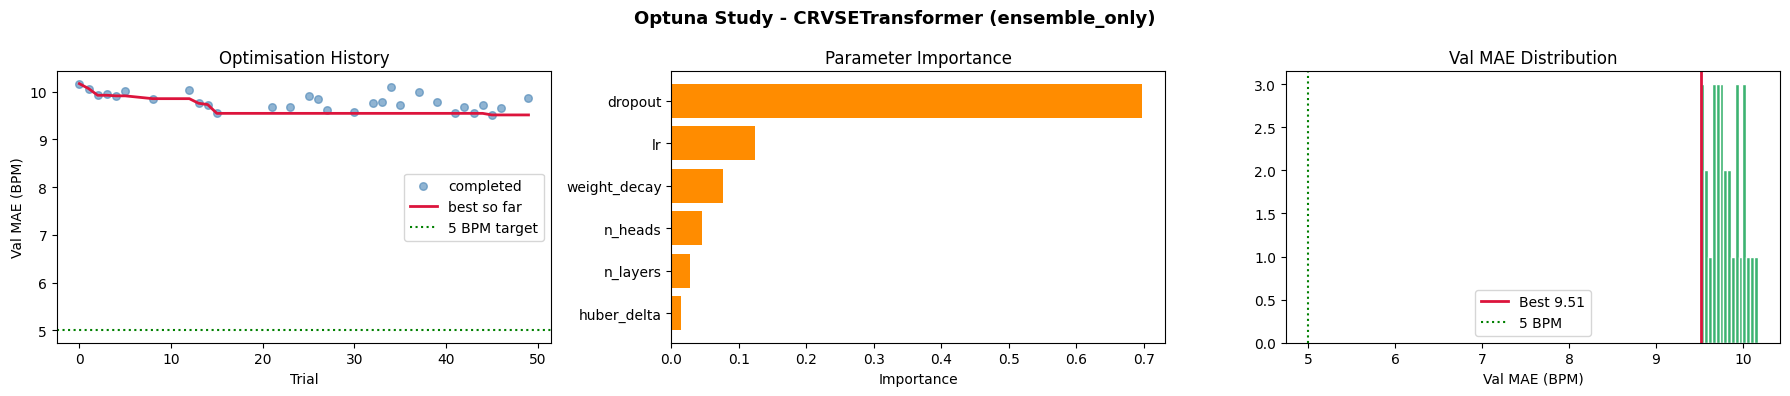

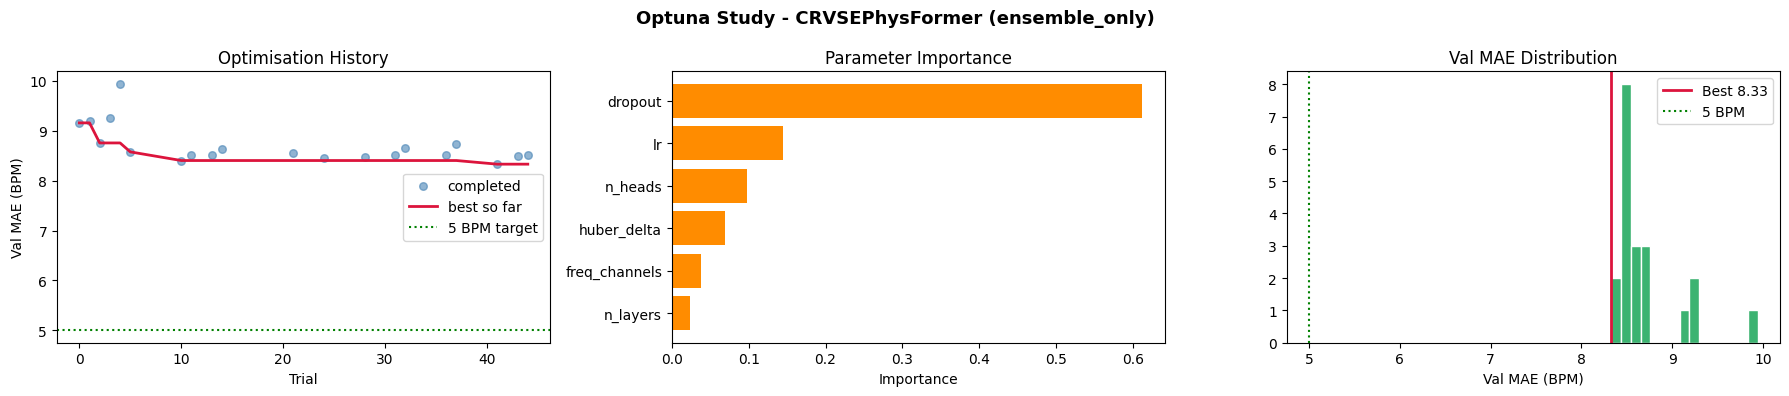

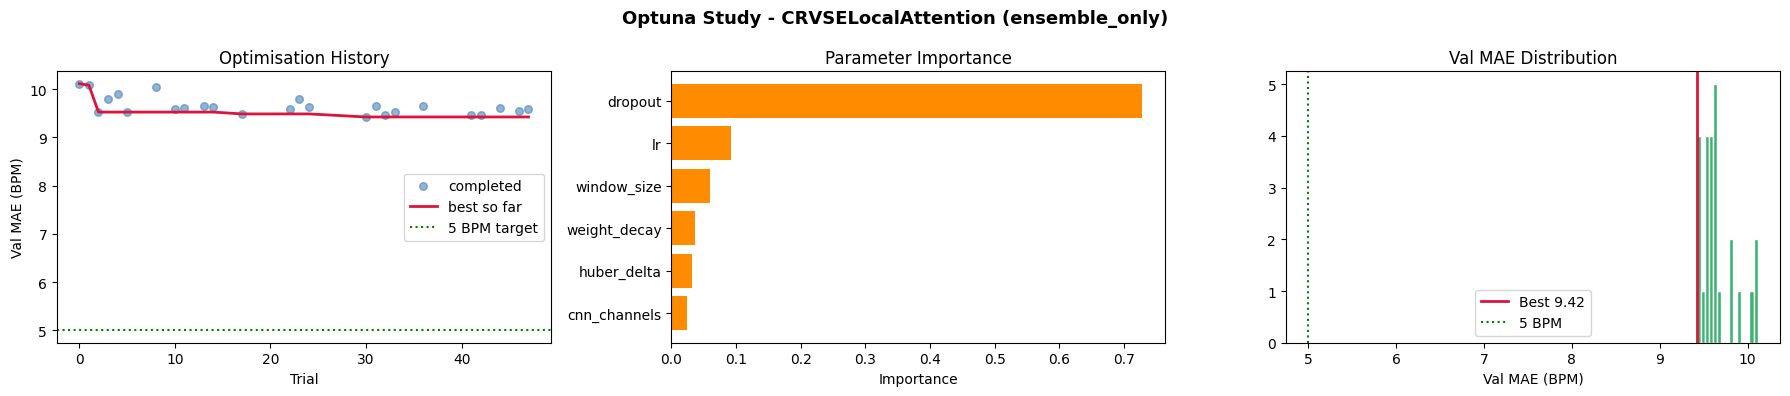

In [18]:
def plot_study(study: optuna.Study, arch_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value for t in trials]
    best_curve = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Optuna Study - {arch_name} ({INPUT_MODE})", fontweight="bold", fontsize=13)

    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_curve, color="crimson", linewidth=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History"); axes[0].legend()

    try:
        importances = optuna.importance.get_param_importances(study)
        params, imps = zip(*list(importances.items())[:6])
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance"); axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Not available", ha="center", va="center", transform=axes[1].transAxes)

    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", linewidth=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM")
    axes[2].set_xlabel("Val MAE (BPM)"); axes[2].set_title("Val MAE Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"optuna_{arch_name.lower()}_{STUDY_TAG}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Plot all three studies
for arch_name, study in [("CRVSETransformer", study_transformer),
                         ("CRVSEPhysFormer", study_physformer),
                         ("CRVSELocalAttention", study_local)]:
    plot_study(study, arch_name)

## 12. Final Training on Best Configuration

Each architecture is retrained on train + val combined using its winning hyperparameters,
then evaluated on the held-out test set.

In [19]:
def retrain_best(name: str, model_class: type, study: optuna.Study, arch_keys: list, save_path: str) -> nn.Module:
    """Retrain best trial config on train+val, save checkpoint. Returns the trained model."""
    p = study.best_params
    best_n_epochs = study.best_trial.last_step

    print(f"\n{'='*50}")
    print(f"Retraining {name} ({INPUT_MODE})")
    print(f"Best trial : #{study.best_trial.number} | best val MAE : {study.best_value:.2f} BPM")
    print(f"Epochs to retrain : {best_n_epochs}")
    print(f"{'='*50}")

    arch_kwargs = {key: p[key] for key in arch_keys if key in p}

    model = model_class(
        in_channels = IN_CHANNELS,
        dropout = p["dropout"],
        hr_min = HR_MIN,
        hr_max = HR_MAX,
        **arch_kwargs,
    ).to(DEVICE)

    full_ds = CRVSEDataset(all_samples, train_keys | val_keys, input_mode=INPUT_MODE)
    full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    print(f"Full train set : {len(full_ds)} windows")

    loss_fn = nn.HuberLoss(delta=p["huber_delta"])
    optimizer = AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=best_n_epochs, eta_min=p["lr"] / 100)

    epoch_bar = tqdm(range(1, best_n_epochs + 1), desc=f"Training {name}", unit="epoch")
    for epoch in epoch_bar:
        model.train()
        total_loss = 0.0
        for signals, labels in full_loader:
            signals, labels = signals.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(signals), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        epoch_bar.set_postfix({"loss": f"{total_loss / len(full_loader):.3f}"})

    torch.save({
        "input_mode": INPUT_MODE,
        "in_channels": IN_CHANNELS,
        "best_params": p,
        "best_n_epochs": best_n_epochs,
        "best_val_mae": study.best_value,
        "model_state": model.state_dict(),
    }, save_path)
    print(f"Saved -> {save_path}")

    return model


# Architecture keys per model
TRANSFORMER_ARCH_KEYS = ["cnn_channels", "n_heads", "n_layers", "dim_feedforward"]
PHYSFORMER_ARCH_KEYS  = ["cnn_channels", "freq_channels", "n_heads", "n_layers", "dim_feedforward"]
LOCAL_ARCH_KEYS = ["cnn_channels", "n_heads", "n_layers", "window_size", "dim_feedforward"]

# Retrain all three
model_transformer = retrain_best(
    "CRVSETransformer", CRVSETransformer, study_transformer, TRANSFORMER_ARCH_KEYS,
    f"{MODEL_NAME}_transformer_{INPUT_MODE}_best.pt",
)
model_physformer = retrain_best(
    "CRVSEPhysFormer", CRVSEPhysFormer, study_physformer, PHYSFORMER_ARCH_KEYS,
    f"{MODEL_NAME}_physformer_{INPUT_MODE}_best.pt",
)
model_local = retrain_best(
    "CRVSELocalAttention", CRVSELocalAttention, study_local, LOCAL_ARCH_KEYS,
    f"{MODEL_NAME}_local_{INPUT_MODE}_best.pt",
)


Retraining CRVSETransformer (ensemble_only)
Best trial : #45 | best val MAE : 9.51 BPM
Epochs to retrain : 50
Dataset size: 15946 windows (mode=ensemble_only)
Full train set : 15946 windows


Training CRVSETransformer: 100%|██████████| 50/50 [05:05<00:00,  6.11s/epoch, loss=49.882]


Saved -> CRVSETransformer_Ensemble_transformer_ensemble_only_best.pt

Retraining CRVSEPhysFormer (ensemble_only)
Best trial : #41 | best val MAE : 8.33 BPM
Epochs to retrain : 50
Dataset size: 15946 windows (mode=ensemble_only)
Full train set : 15946 windows


Training CRVSEPhysFormer: 100%|██████████| 50/50 [10:26<00:00, 12.52s/epoch, loss=39.870]


Saved -> CRVSETransformer_Ensemble_physformer_ensemble_only_best.pt

Retraining CRVSELocalAttention (ensemble_only)
Best trial : #30 | best val MAE : 9.42 BPM
Epochs to retrain : 50
Dataset size: 15946 windows (mode=ensemble_only)
Full train set : 15946 windows


Training CRVSELocalAttention: 100%|██████████| 50/50 [03:52<00:00,  4.65s/epoch, loss=70.527]

Saved -> CRVSETransformer_Ensemble_local_ensemble_only_best.pt


## 13. Full Evaluation - all three models on test set

In [20]:
def collect_predictions(model: nn.Module, loader: DataLoader, ds: CRVSEDataset) -> tuple:
    """Collect predictions, labels, subject_ids, dataset_ids from a loader."""
    model.eval()
    preds_list, labels_list = [], []

    with torch.inference_mode():
        for signals, labels in loader:
            preds = model(signals.to(DEVICE)).cpu().numpy()
            preds_list.extend(preds.tolist())
            labels_list.extend(labels.numpy().tolist())

    subject_ids = [ds.items[i]["subject_key"] for i in range(len(ds))]
    dataset_ids = [ds.items[i]["dataset"] for i in range(len(ds))]

    return (
        np.array(preds_list,  dtype=np.float32),
        np.array(labels_list, dtype=np.float32),
        subject_ids,
        dataset_ids,
    )


results = {}

for name, model in [("CRVSETransformer", model_transformer),
                    ("CRVSEPhysFormer", model_physformer),
                    ("CRVSELocalAttention", model_local)]:
    preds, labels, subj_ids, ds_ids = collect_predictions(model, test_loader, test_ds)
    full_evaluation(preds=preds, labels=labels, subject_ids=subj_ids, dataset_ids=ds_ids,
                    model_name=f"{name} - {INPUT_MODE}")
    results[name] = {"preds": preds, "labels": labels, "subj": subj_ids, "ds": ds_ids}


FULL EVALUATION - CRVSETransformer - ensemble_only

Window-level (n=3106 windows):
MAE : 9.45 BPM
RMSE : 14.13 BPM
MAPE : 11.04 %
Pearson r : 0.5380  (p=0.0000)
R2 : 0.2584
BA bias : -2.37 BPM
BA LoA : [-29.67, 24.92] BPM

|error| <  5 BPM : 40.1% of windows
|error| < 10 BPM : 67.0% of windows
|error| < 15 BPM : 82.6% of windows

Subject-level metrics (n=52 subjects):
MAE : 7.32 BPM
RMSE : 11.35 BPM
r : 0.7177
BA bias: -2.59 BPM
BA LoA : [-24.25, 19.08] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
ecg_fitness       278    28.56    35.02   0.0448
mcd_rppg         2094     7.49     9.80   0.7073
ubfc_phys         658     8.07    10.55   0.1894
ubfc_rppg          76     5.57     7.79   0.9288

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          370    10.37    12.80
normal low              1657     5.88     7.45
normal hi

## 14. Round 4 - Transformer ensemble comparison

In [21]:
def transformer_comparison(results: dict) -> tuple:
    """Print Round 4 Transformer comparison table; return (best_name, rows)."""
    print("\n" + "=" * 78)
    print(f"ROUND 4 - TRANSFORMER VARIANTS COMPARISON | input_mode = {INPUT_MODE}")
    print("=" * 78)

    rows = {}
    for name, r in results.items():
        diff = r["preds"] - r["labels"]
        mae = float(np.mean(np.abs(diff)))
        rmse = float(np.sqrt(np.mean(diff ** 2)))
        pearr, _ = stats.pearsonr(r["preds"], r["labels"])
        r2 = float(1 - np.sum(diff**2) / np.sum((r["labels"] - r["labels"].mean())**2))
        ba_bias = float(diff.mean())
        cov5 = float(np.mean(np.abs(diff) < 5) * 100)

        # subject-level MAE (the headline metric)
        subj_p = defaultdict(list); subj_l = defaultdict(list)
        for p, l, s in zip(r["preds"], r["labels"], r["subj"]):
            subj_p[s].append(p); subj_l[s].append(l)
        sp = np.array([np.mean(v) for v in subj_p.values()])
        sl = np.array([np.mean(v) for v in subj_l.values()])
        subj_mae = float(np.mean(np.abs(sp - sl)))

        rows[name] = dict(mae=mae, subj_mae=subj_mae, rmse=rmse, r=float(pearr),
                          r2=r2, ba_bias=ba_bias, cov5=cov5)

    hdr = f"{'Model':<22} {'win MAE':>8} {'subj MAE':>9} {'RMSE':>7} {'r':>7} {'R2':>7} {'BA bias':>8} {'<5BPM%':>8}"
    print(hdr)
    print("-" * len(hdr))
    for name, m in rows.items():
        print(f"{name:<22} {m['mae']:>8.2f} {m['subj_mae']:>9.2f} {m['rmse']:>7.2f} "
              f"{m['r']:>7.4f} {m['r2']:>7.4f} {m['ba_bias']:>8.2f} {m['cov5']:>7.1f}%")

    best_name = min(rows, key=lambda n: rows[n]["subj_mae"])
    print(f"\nBest ({INPUT_MODE}) : {best_name} - subject MAE {rows[best_name]['subj_mae']:.2f} BPM")
    return best_name, rows


best_transformer, comparison_rows = transformer_comparison(results)

# Save best params + headline metrics for cross-notebook reference
summary = {
    "input_mode": INPUT_MODE,
    "in_channels": IN_CHANNELS,
    "best_variant": best_transformer,
    "variants": {},
}
for name, study in [("CRVSETransformer", study_transformer),
                    ("CRVSEPhysFormer", study_physformer),
                    ("CRVSELocalAttention", study_local)]:
    summary["variants"][name] = {
        "best_val_mae": float(study.best_value),
        "best_trial": int(study.best_trial.number),
        "best_n_epochs": int(study.best_trial.last_step),
        "best_params": study.best_params,
        "test_subj_mae": float(comparison_rows[name]["subj_mae"]),
        "test_window_mae": float(comparison_rows[name]["mae"]),
        "test_r": float(comparison_rows[name]["r"]),
    }

params_file = f"{MODEL_NAME}_{INPUT_MODE}_best_params.json"
with open(params_file, "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nParams -> {params_file}")


ROUND 4 - TRANSFORMER VARIANTS COMPARISON | input_mode = ensemble_only
Model                   win MAE  subj MAE    RMSE       r      R2  BA bias   <5BPM%
-----------------------------------------------------------------------------------
CRVSETransformer           9.45      7.32   14.13  0.5380  0.2584    -2.37    40.1%
CRVSEPhysFormer            7.36      4.55   12.48  0.6694  0.4210     0.22    59.5%
CRVSELocalAttention        9.49      7.30   13.97  0.5461  0.2745    -1.67    39.2%

Best (ensemble_only) : CRVSEPhysFormer - subject MAE 4.55 BPM

Params -> CRVSETransformer_Ensemble_ensemble_only_best_params.json
